In [18]:
# =========================
# 1. IMPORTS
# =========================
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("plant_data.csv")

print("Columns:", df.columns)

# Fix column names if needed
if 'text' not in df.columns:
    df.rename(columns={df.columns[0]: 'text'}, inplace=True)

if 'label' not in df.columns:
    df.rename(columns={df.columns[1]: 'label'}, inplace=True)

# Remove null values
df = df[['text', 'label']].dropna()

print("Dataset size:", len(df))

# =========================
# 3. ENCODE LABELS
# =========================
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['label'])

num_labels = len(df['label'].unique())
print("Number of labels:", num_labels)

# =========================
# 4. TRAIN-TEST SPLIT
# =========================
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    random_state=42
)

# =========================
# 5. TOKENIZATION
# =========================
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(example):
    return tokenizer(
        example['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

train_dataset = Dataset.from_dict({
    'text': train_texts.tolist(),
    'label': train_labels.tolist()
})

val_dataset = Dataset.from_dict({
    'text': val_texts.tolist(),
    'label': val_labels.tolist()
})

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
val_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

# =========================
# 6. LOAD MODEL
# =========================
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=num_labels
)

# =========================
# 7. TRAINING ARGUMENTS (SAFE VERSION)
# =========================
training_args = TrainingArguments(
    output_dir='./results',
    logging_dir='./logs',
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01
)

# =========================
# 8. TRAINER
# =========================
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

# =========================
# 9. TRAIN MODEL
# =========================
trainer.train()

# =========================
# 10. SAVE MODEL
# =========================
model.save_pretrained("./bert_model")
tokenizer.save_pretrained("./bert_model")

print("✅ Training completed!")

# =========================
# 11. PREDICTION FUNCTION
# =========================
def predict(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    outputs = model(**inputs)
    logits = outputs.logits
    predicted_class_id = torch.argmax(logits).item()
    return label_encoder.inverse_transform([predicted_class_id])[0]

# =========================
# 12. TEST PREDICTION
# =========================
print(predict("leaf has brown spots"))

Columns: Index(['text', 'label'], dtype='object')
Dataset size: 950
Number of labels: 19


Map:   0%|          | 0/760 [00:00<?, ? examples/s]

Map:   0%|          | 0/190 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

Step,Training Loss


KeyboardInterrupt: 

In [19]:
!pip install pandas scikit-learn transformers datasets torch matplotlib

In [20]:
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

In [21]:
df = pd.read_csv("plant_data.csv")

print("Columns:", df.columns)

# Fix column names
if 'text' not in df.columns:
    df.rename(columns={df.columns[0]: 'text'}, inplace=True)

if 'label' not in df.columns:
    df.rename(columns={df.columns[1]: 'label'}, inplace=True)

df = df[['text', 'label']].dropna()

print(df.head())

Columns: Index(['text', 'label'], dtype='object')
                              text                label
0  plant affected with dry patches  Tomato Early Blight
1          leaves have dry patches  Tomato Early Blight
2       clear signs of brown spots  Tomato Early Blight
3    plant leaves show dry patches  Tomato Early Blight
4       clear signs of brown spots  Tomato Early Blight


In [22]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['label'])

num_labels = len(df['label'].unique())
print("Number of labels:", num_labels)

Number of labels: 19


In [23]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    random_state=42
)

In [24]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(example):
    return tokenizer(
        example['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

train_dataset = Dataset.from_dict({
    'text': train_texts.tolist(),
    'label': train_labels.tolist()
})

val_dataset = Dataset.from_dict({
    'text': val_texts.tolist(),
    'label': val_labels.tolist()
})

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
val_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

Map:   0%|          | 0/760 [00:00<?, ? examples/s]

Map:   0%|          | 0/190 [00:00<?, ? examples/s]

In [25]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=num_labels
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [26]:
training_args = TrainingArguments(
    output_dir='./results',
    do_train=True,
    do_eval=True,
    logging_steps=10,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3
)

In [27]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

In [28]:
trainer.train()

c:\Users\Sreelakshmi\Desktop\PlantDocBot_project\venv310\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
10,2.998722
20,2.923282
30,2.962197
40,2.944026
50,2.874064
60,2.822787
70,2.759419
80,2.595928
90,2.641710
100,2.399775


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=285, training_loss=1.7406028630440695, metrics={'train_runtime': 1563.1782, 'train_samples_per_second': 1.459, 'train_steps_per_second': 0.182, 'total_flos': 149996192901120.0, 'train_loss': 1.7406028630440695, 'epoch': 3.0})

In [29]:
print("Running Evaluation...")

results = trainer.predict(val_dataset)

preds = np.argmax(results.predictions, axis=1)
labels = results.label_ids

precision, recall, f1, _ = precision_recall_fscore_support(
    labels, preds, average='weighted'
)
accuracy = accuracy_score(labels, preds)

print("\n📊 Results:")
print(f"Accuracy : {accuracy:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")

Running Evaluation...


c:\Users\Sreelakshmi\Desktop\PlantDocBot_project\venv310\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



📊 Results:
Accuracy : 0.9579
F1 Score : 0.9562
Precision: 0.9648
Recall   : 0.9579


In [30]:
model.save_pretrained("./bert_model")
tokenizer.save_pretrained("./bert_model")

print("✅ Model saved!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved!


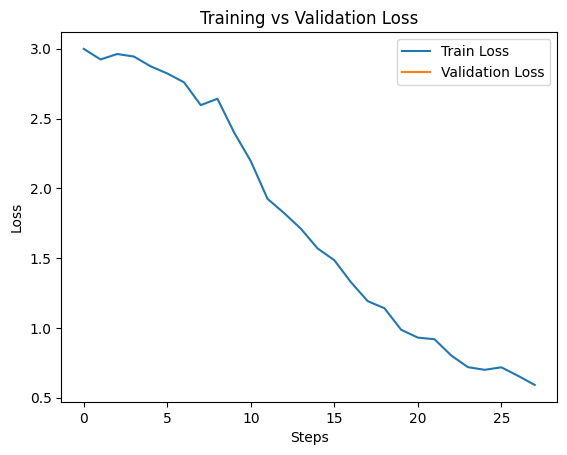

In [31]:
logs = trainer.state.log_history

train_loss = [x['loss'] for x in logs if 'loss' in x]
eval_loss = [x['eval_loss'] for x in logs if 'eval_loss' in x]

plt.figure()
plt.plot(train_loss, label='Train Loss')
plt.plot(eval_loss, label='Validation Loss')
plt.legend()
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.show()

In [32]:
def predict(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    outputs = model(**inputs)
    logits = outputs.logits
    pred = torch.argmax(logits).item()
    return label_encoder.inverse_transform([pred])[0]

# Test
print(predict("leaf has yellow spots"))

Banana Sigatoka
